# Task2 鐠囪鍤拠顖氭▕

濡剝瀚欑搾鍛嚤闁插繐鐡欏В鏃傚鐠囪鍤稉顓犳畱閼垫柨鎼锋惔鏂挎嫲濞村鍣洪柧鍙ヤ繆閸欏嚖绱濇担鍡氱箹闁插奔绗夐崘宥嗘▔瀵繑膩閹风喕鍘伴惃鍕櫤鐎涙劖鈧緤绱濋懓灞炬Ц閻劋绔存稉顏嗙病閸忕顦查幐顖氱畽 `alpha(t)` 閺夈儲寮挎潻鎷屽幇閸︾儤绱ㄩ崠鏍モ偓鍌涚槷閻楄婀伴煬顐＄瑝娴ｆ粈璐熺€瑰本鏆ｉ柌蹇撶摍閹胶鈹栭梻瀛樼川閸栨牭绱濋懓灞藉涧閺勵垶鈧俺绻?`0/1` 娑撱倗顫掗悩鑸碘偓浣割嚠鎼存柧绗夐崥宀€娈戦懙鏃堫暥缁変紮绱濋弶銉ょ秼閻滄媽澹婇弫锝堫嚢閸戣櫣娈戦悩鑸碘偓浣风贩鐠ф牗鈧佲偓淇搉
鏉╂瑤閲滄禒璇插娑撳秴浠涚€瑰本鏆ｉ惃鍕櫤鐎涙劖绁撮柌蹇撳冀妫ｅ牞绱濋懓灞炬Ц閺囩鍒涙潻鎴濈杽妤犲奔淇婇崣鐑芥懠閸︽澘骞撻惇瀣剁窗
- 鏉堟挸鍙嗙拠璇插毉閼村鍟?`a_in`
- ADC 闁插洦鐗辨穱鈥冲娇
- 閸╄桨绨?ADC 閺佹澘鐡х憴锝堢殶閸氬海娈?IQ 閸掋倕鍩嗙紒鎾寸亯

閻╊喖澧?`task2` 姒涙顓婚柌鍥╂暏閳ユ粎娲块崣鎴犳纯闁插洠鈧繃膩瀵骏绱濇稊鐔锋皑閺勵垳娲块幒銉ヮ嚠 RF 娣団€冲娇鏉╂稖顢?ADC 闁插洦鐗遍妴鍌濈箹閺嶇柉娴囧▔銏ゎ暥閻滃洤鎷伴柌鍥ㄧ壉閻滃洤鍙￠崥灞藉枀鐎规矮绨?alias 妫版垹宸奸敍灞芥倵缂侇厾娈?IQ 閹绘劕褰囨稊鐔告Ц閸╄桨绨?ADC 娣団€冲娇鐎瑰本鍨氶惃鍕┾偓鍌炴珟濮濄倓绠ｆ径鏍电礉鏉╂瑤閲滄禒璇插娑旂喐鏁幐浣测偓婊€绗呴崣姗€顣堕垾婵嚹佸蹇ョ礉閻劍娼靛Ο鈩冨珯閸忓牊璐╂０鎴濆煂 IF 閸愬秹鍣伴弽椋庢畱閹懎鑸伴妴淇搉
閹崵娈戦弶銉嚛閿涘畭task2` 閺囨挳鈧倸鎮庨崑姘愁嚢閸戞椽鎽肩捄顖氭嫲鐎圭偤鐛欏▔銏犺埌鐏炲倿娼伴惃鍕瀻閺嬫劧绱濆В鏂款洤閻?IQ 閺侊絿鍋ｉ妴浣稿閻滃洩姘ㄩ妴渚€鍣伴弽椋庡芳閸?alias 閻ㄥ嫬濂栭崫宥忕礉娴犮儱寮锋潏鎾冲弳閸ｎ亜锛愭俊鍌欑秿娴肩姴鍩岄張鈧紒鍫熺ゴ闁插繒绮ㄩ弸婧库偓?

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from workflow import create_model

def pairs_to_complex(values):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        return arr.astype(complex)
    return arr[:, 0] + 1j * arr[:, 1]


TASK_DIR = Path("task2")

In [2]:
model = create_model(task_config=TASK_DIR / 'task.yaml')
solver_id = next(iter(model.solvers))
model.solvers[solver_id].run.mcwf_ntraj = 1000
model.run_all()

print('solver keys =', sorted(model.results.solver_runs.keys()))
print('analysis keys =', sorted(model.results.analyses.keys()))


solver keys = ['solver_0', 'solver_0__prep_0', 'solver_0__prep_1']
analysis keys = ['analyser_0', 'analyser_0__prep_0', 'analyser_0__prep_1']


In [3]:
study_0 = 'prep_0'
study_1 = 'prep_1'
tr0 = model.get_trajectory(solver_id, study_name=study_0)
tr1 = model.get_trajectory(solver_id, study_name=study_1)
ana0 = model.get_analysis(analyser_id='analyser_0', study_name=study_0)
ana1 = model.get_analysis(analyser_id='analyser_0', study_name=study_1)

print('readout keys prep_0 =', sorted((tr0.classical or {}).get('readout', {}).keys()))
print('iq labels prep_0 =', list((ana0.iq or {}).get('synthetic_clouds', {}).keys()))
print('iq labels prep_1 =', list((ana1.iq or {}).get('synthetic_clouds', {}).keys()))


readout keys prep_0 = ['a_in', 'a_out', 'cavity_a', 'cavity_n', 'chain', 'equations', 'feedback', 'heterodyne_current', 'line_state', 'measured_voltage', 'shots', 'times']
iq labels prep_0 = ['state_0']
iq labels prep_1 = ['state_0']


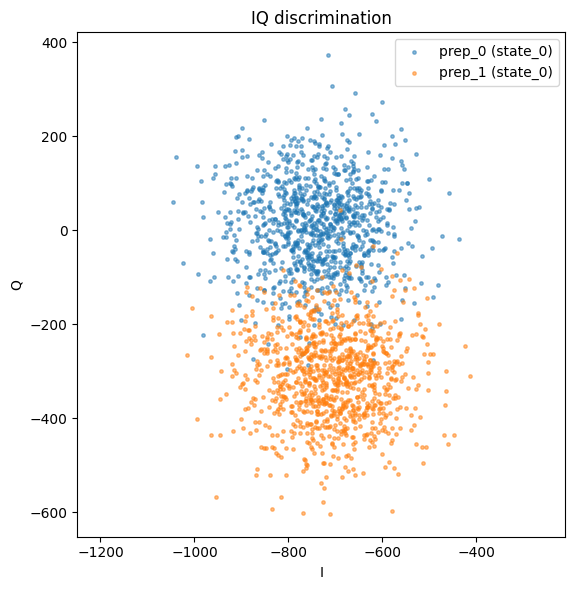

In [4]:
def cloud_points(analysis):
    iq = dict(analysis.iq or {})
    clouds = dict(iq.get('synthetic_clouds', {}) or {})
    if clouds:
        label, points = next(iter(clouds.items()))
        pts = np.asarray(points, dtype=float)
        return label, pts
    samples = list(iq.get('samples', []) or [])
    if samples:
        point = np.asarray(samples[0].get('integrated_iq', [0.0, 0.0]), dtype=float)
        return str(samples[0].get('label', 'state')), point.reshape(1, 2)
    return 'state', np.zeros((1, 2), dtype=float)

label0, pts0 = cloud_points(ana0)
label1, pts1 = cloud_points(ana1)

plt.figure(figsize=(6, 6))
plt.scatter(pts0[:, 0], pts0[:, 1], s=6, alpha=0.5, label=f'prep_0 ({label0})')
plt.scatter(pts1[:, 0], pts1[:, 1], s=6, alpha=0.5, label=f'prep_1 ({label1})')
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ discrimination')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


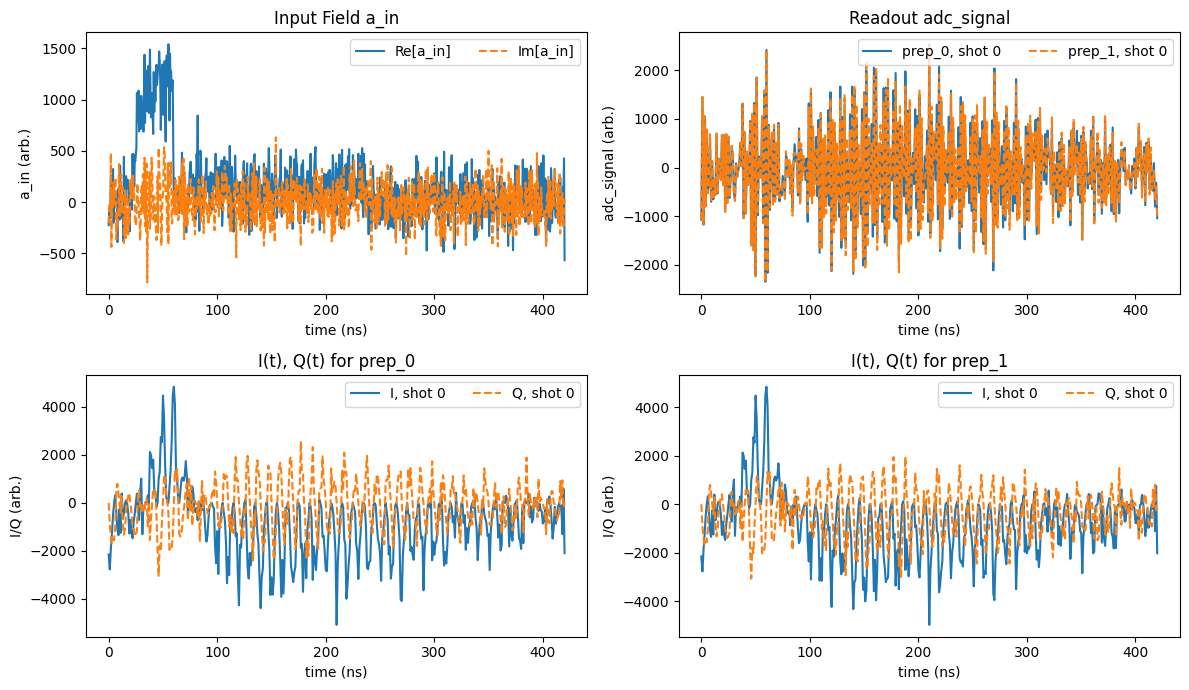

In [5]:
shot_index = 0

t_in_ns_0 = np.asarray(tr0.classical['readout']['times'], dtype=float) * 1e9
t_in_ns_1 = np.asarray(tr1.classical['readout']['times'], dtype=float) * 1e9
a_in0 = pairs_to_complex(tr0.classical['readout']['shots'][shot_index]['a_in'])
a_in1 = pairs_to_complex(tr1.classical['readout']['shots'][shot_index]['a_in'])


t_adc_ns_0 = np.asarray(ana0.readout['shots'][0]['adc_times'], dtype=float) * 1e9
t_adc_ns_1 = np.asarray(ana1.readout['shots'][0]['adc_times'], dtype=float) * 1e9
v0 = pairs_to_complex(ana0.readout['shots'][shot_index]['adc_signal'])
v1 = pairs_to_complex(ana1.readout['shots'][shot_index]['adc_signal'])
iq0 = pairs_to_complex(ana0.readout['shots'][shot_index]['digital_baseband'])
iq1 = pairs_to_complex(ana1.readout['shots'][shot_index]['digital_baseband'])

fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
ax[0, 0].plot(t_in_ns_0, a_in0.real, label='Re[a_in]')
ax[0, 0].plot(t_in_ns_0, a_in0.imag, '--', label='Im[a_in]')
ax[0, 0].set_title('Input Field a_in')
ax[0, 0].set_xlabel('time (ns)')
ax[0, 0].set_ylabel('a_in (arb.)')
ax[0, 0].legend(ncol=2)

ax[0, 1].plot(t_adc_ns_0, v0.real, label=f'prep_0, shot {shot_index}')
ax[0, 1].plot(t_adc_ns_0, v1.real, '--', label=f'prep_1, shot {shot_index}')
ax[0, 1].set_title('Readout adc_signal')
ax[0, 1].set_xlabel('time (ns)')
ax[0, 1].set_ylabel('adc_signal (arb.)')
ax[0, 1].legend(ncol=2)

ax[1, 0].plot(t_adc_ns_0, iq0.real, label=f'I, shot {shot_index}')
ax[1, 0].plot(t_adc_ns_0, iq0.imag, '--', label=f'Q, shot {shot_index}')
ax[1, 0].set_title('I(t), Q(t) for prep_0')
ax[1, 0].set_xlabel('time (ns)')
ax[1, 0].set_ylabel('I/Q (arb.)')
ax[1, 0].legend(ncol=2)

ax[1, 1].plot(t_adc_ns_0, iq1.real, label=f'I, shot {shot_index}')
ax[1, 1].plot(t_adc_ns_0, iq1.imag, '--', label=f'Q, shot {shot_index}')
ax[1, 1].set_title('I(t), Q(t) for prep_1')
ax[1, 1].set_xlabel('time (ns)')
ax[1, 1].set_ylabel('I/Q (arb.)')
ax[1, 1].legend(ncol=2)

plt.tight_layout()
plt.show()


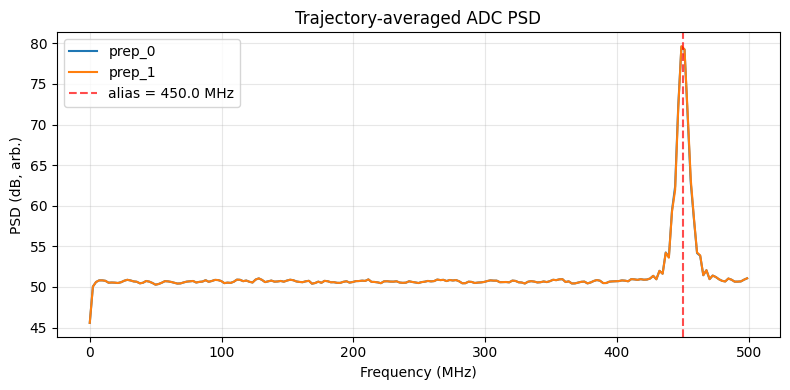

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def avg_psd_real_shots(adc_times, adc_shots, window="hann", remove_dc=True):
    t = np.asarray(adc_times, dtype=float)
    dt = float(np.mean(np.diff(t)))
    n = len(t)

    if window == "hann":
        w = np.hanning(n)
    else:
        w = np.ones(n)

    norm = np.sum(w**2)
    freqs = np.fft.rfftfreq(n, d=dt)

    psd_all = []
    for x in adc_shots:
        x = np.asarray(x, dtype=float)
        if remove_dc:
            x = x - np.mean(x)
        X = np.fft.rfft(x * w)
        psd = (np.abs(X) ** 2) / norm
        psd_all.append(psd)

    psd_all = np.asarray(psd_all, dtype=float)
    return freqs, psd_all.mean(axis=0), psd_all.std(axis=0), psd_all


solver_id = next(iter(model.solvers))
analyser_id = next(iter(model.analysers))

study_names = ["prep_0", "prep_1"]

fig, ax = plt.subplots(figsize=(8, 4))

for study_name in study_names:
    ana = model.get_analysis(analyser_id=analyser_id, study_name=study_name)
    ro = ana.readout

    adc_times = np.asarray(ro["adc_times"], dtype=float)
    shot_payloads = ro.get("shots", [])

    adc_shots = [np.asarray(shot["adc_signal"], dtype=float) for shot in shot_payloads if shot.get("adc_signal")]
    if not adc_shots:
        raise RuntimeError(f"{study_name} 濞屸剝婀?shot 缁?adc_signal")

    freqs, psd_mean, psd_std, _ = avg_psd_real_shots(
        adc_times,
        adc_shots,
        window="hann",
        remove_dc=True,
    )

    ax.plot(freqs / 1e6, 10 * np.log10(psd_mean + 1e-30), label=study_name)

alias_MHz = ro["receiver"]["alias_frequency_Hz"] / 1e6
ax.axvline(alias_MHz, color="r", linestyle="--", alpha=0.7, label=f"alias = {alias_MHz:.1f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("PSD (dB, arb.)")
ax.set_title("Trajectory-averaged ADC PSD")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
comparison_iq = model.results.analyses['analyser_0'].iq
print('aggregate IQ summary:')
for label, center in sorted((comparison_iq or {}).get('centroids', {}).items()):
    print(label, center)


aggregate IQ summary:
0 [-741.5430090387252, 12.215199751717314]
1 [-710.5092494986039, -309.590996033229]
